# Проект спринта 27. Часть 1: анализ и подготовка данных

Это первая из двух тетрадок, в которых вы будете выполнять проект по извлечению именованных сущностей (NER). Здесь вы познакомитесь с разметкой WikiANN, исследуете русскоязычную часть датасета и подготовите её для BERT: токенизируете предложения и выровняете NER-метки
с подтокенами.

**Датасет:** [WikiANN](https://huggingface.co/datasets/unimelb-nlp/wikiann), русскоязычная
конфигурация. Типы сущностей: `PER`, `ORG`, `LOC`. Схема разметки — IOB2.

**Токенизатор:** `bert-base-multilingual-cased`.

## Шаг 1. Подготовка окружения и обеспечение воспроизводимости

Установите зависимости, импортируйте библиотеки и зафиксируйте `SEED`.

In [66]:
# Установка библиотек
%pip install -q numpy pandas matplotlib torch transformers datasets seqeval spacy

In [67]:
import statistics
from collections import Counter
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from seqeval.metrics.sequence_labeling import get_entities
from spacy import displacy
from transformers import (
    AutoTokenizer,
    DataCollatorForTokenClassification,
    set_seed,
)


In [68]:
SEED = 42
set_seed(SEED)

print("Версии: " + ", ".join(
    f"{package}={version(package)}"
    for package in [
        "torch",
        "transformers",
        "datasets",
        "seqeval",
        "spacy",
    ]
))

Версии: torch=2.11.0+cpu, transformers=5.15.1, datasets=4.0.0, seqeval=1.2.2, spacy=3.8.16


## Шаг 2. Знакомство с данными и их анализ

WikiANN построен автоматически на основе статей Википедии. Один пример содержит
исходные `tokens`, числовые `ner_tags` и служебные поля `langs`, `spans`.

В IOB2 каждая новая сущность начинается с `B-*`, её продолжение размечается `I-*`,
а токены вне сущностей — `O`. При подсчёте распределения одна метка `B-*`
соответствует одной сущности.


In [69]:
# Загрузка русскоязычной конфигурации WikiANN
raw_datasets = load_dataset("unimelb-nlp/wikiann", "ru")

print(f"Размер обучающей выборки:   {len(raw_datasets['train'])}")
print(f"Размер валидационной:       {len(raw_datasets['validation'])}")
print(f"Размер тестовой:            {len(raw_datasets['test'])}")

# Получаем метки из структуры датасета
label_list = raw_datasets["train"].features["ner_tags"].feature.names
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}
ENTITY_TYPES = sorted({
    label.split("-")[-1]
    for label in label_list
    if label != "O"
})

print(f"Метки: {label_list}")
print(f"Типы сущностей: {ENTITY_TYPES}")


Размер обучающей выборки:   20000
Размер валидационной:       10000
Размер тестовой:            10000
Метки: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
Типы сущностей: ['LOC', 'ORG', 'PER']


### Анализ примеров разметки

Выведите первые два примера из обучающей выборки. Покажите исходный текст и пары «токен — строковая метка» для размеченных сущностей.


In [70]:
for i in range(2):
    tokens = raw_datasets["train"][i]["tokens"]
    tags = [label_list[tag] for tag in raw_datasets["train"][i]["ner_tags"]]

    print(f"Пример {i + 1}: {" ".join(tokens)}")
    for token, tag in zip(tokens, tags):
        print(f"    {token:<20} -> {tag}")
    print()

Пример 1: Илизаров , Гавриил Абрамович
    Илизаров             -> B-PER
    ,                    -> I-PER
    Гавриил              -> I-PER
    Абрамович            -> I-PER

Пример 2: ' '' Рыбницкий район '' '
    '                    -> O
    ''                   -> O
    Рыбницкий            -> B-LOC
    район                -> I-LOC
    ''                   -> O
    '                    -> O



### Демонстрация сущностей

Используйте готовую функцию и выведите три предложения из валидационной выборки, в которых подсвечены размеченные сущности. Проверьте, что многословные сущности отображаются единым фрагментом.


In [71]:
def visualize_ner(example, label_list):
    """Подсвечивает целые IOB2-сущности в одном примере WikiANN."""
    tokens = example["tokens"]
    tags = [label_list[tag] for tag in example["ner_tags"]]
    text = " ".join(tokens)

    offsets = []
    cursor = 0
    for token in tokens:
        offsets.append((cursor, cursor + len(token)))
        cursor += len(token) + 1

    ents = [
        {
            "start": offsets[start][0],
            "end": offsets[end][1],
            "label": entity_type,
        }
        for entity_type, start, end in get_entities(tags)
    ]
    displacy.render(
        {"text": text, "ents": ents},
        style="ent",
        manual=True,
        jupyter=True,
    )

for i in range(3):
    example = raw_datasets["validation"][i]
    visualize_ner(example, label_list)

### Анализ распределения сущностей

На обучающей выборке посчитайте количество сущностей `PER`, `ORG`, `LOC` по меткам `B-*`,
выведите полученные значения и отобразите их на столбчатой диаграмме. Не считайте `I-*` отдельными сущностями.


LOC: 9498
ORG: 7944
PER: 7187


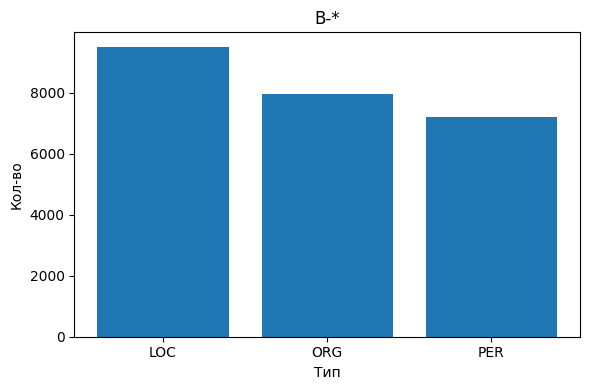

In [72]:
entity_types = [
    id2label[tag].split("-")[-1]
    for example in raw_datasets["train"]["ner_tags"]
    for tag in example
    if id2label[tag].startswith("B-")
]
type_counts = Counter(entity_types)

for ent_type in ENTITY_TYPES:
    print(f"{ent_type}: {type_counts.get(ent_type, 0)}")

plt.figure(figsize=(6, 4))
plt.bar(ENTITY_TYPES, [type_counts.get(t, 0) for t in ENTITY_TYPES])
plt.xlabel("Тип")
plt.ylabel("Кол-во")
plt.title("B-*")
plt.tight_layout()
plt.show()

### Изучение длин предложений

Рассчитайте длины предложений в обучающей выборке по числу исходных `tokens`.
Постройте распределение и выведите минимум, максимум и медиану.


Минимум:  3
Максимум: 54
Медиана:  6.0


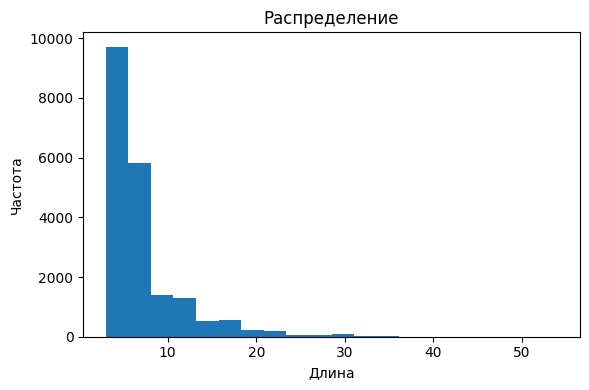

In [73]:
sentence_lengths = [len(tokens) for tokens in raw_datasets['train']['tokens']]

print(f"Минимум:  {min(sentence_lengths)}")
print(f"Максимум: {max(sentence_lengths)}")
print(f"Медиана:  {statistics.median(sentence_lengths)}")


plt.figure(figsize=(6, 4))
plt.hist(sentence_lengths, bins=20)
plt.xlabel("Длина")
plt.ylabel("Частота")
plt.title("Распределение")
plt.tight_layout()
plt.show()

### Выводы

Локации встречаются заметно чаще организаций и персон. Предложения в среднем короткие (медиана - 6 токенов), и это скорее фрагменты текста, чем полноценные фразы, плюс есть длинный хвост из редких длинных предложений. Разметка автоматическая, так что где-то могут быть кривые границы сущностей или пропущенные упоминания.

## Шаг 3. Токенизация и выравнивание меток

BERT может разбить одно исходное слово на несколько токенов-подслов. В этом проекте
исходная NER-метка назначается только первому токену. Продолжения слова,
специальные токены и паддинг получают `-100` и исключаются из расчёта функции потерь.


In [74]:
model_checkpoint = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [75]:
def tokenize_and_align_labels(examples):
    """Токенизирует слова и выравнивает NER-метки с подсловами."""
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
    )

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


### Анализ работы `word_ids()`

С помощью зафиксированного `SEED` выберите два примера из обучающей выборки. Для каждой позиции выведите последовательность значений:

```text
токен → word_id → метка после выравнивания
```

Проверьте специальные токены, первый токен слова и его продолжения.


In [76]:
examples_to_trace = raw_datasets["train"].shuffle(seed=SEED).select(range(2))

for i in range(len(examples_to_trace["tokens"])):
    tokens = examples_to_trace["tokens"][i]
    tags = examples_to_trace["ner_tags"][i]
    tokenized = tokenizer(tokens, is_split_into_words=True)
    word_ids = tokenized.word_ids()
    subtokens = tokenizer.convert_ids_to_tokens(tokenized["input_ids"])

    aligned_labels = tokenize_and_align_labels(
        examples_to_trace[i:i+1]
    )["labels"][0]

    print(f"Пример {i + 1}:")
    for token, word_id, label in zip(subtokens, word_ids, aligned_labels):
        readable = "IGN" if label == -100 else id2label[label]
        print(f"{token:<10} -> {word_id!s:<6} -> {readable}")
    print()

Пример 1:
[CLS]      -> None   -> IGN
'          -> 0      -> O
'          -> 1      -> O
'          -> 1      -> IGN
Польша     -> 2      -> B-LOC
'          -> 3      -> O
'          -> 3      -> IGN
'          -> 4      -> O
[UNK]      -> 5      -> O
[SEP]      -> None   -> IGN

Пример 2:
[CLS]      -> None   -> IGN
К          -> 0      -> O
##арт      -> 0      -> IGN
##ина      -> 0      -> IGN
была       -> 1      -> O
при        -> 2      -> O
##ве       -> 2      -> IGN
##зен      -> 2      -> IGN
##а        -> 2      -> IGN
из         -> 3      -> O
Ф          -> 4      -> B-LOC
##лор      -> 4      -> IGN
##ен       -> 4      -> IGN
##ции      -> 4      -> IGN
в          -> 5      -> O
Мюнхен     -> 6      -> B-LOC
после      -> 7      -> O
почти      -> 8      -> O
два        -> 9      -> O
##д        -> 9      -> IGN
##ца       -> 9      -> IGN
##тил      -> 9      -> IGN
##ет       -> 9      -> IGN
##них      -> 9      -> IGN
пер        -> 10     -> O
##его      -> 10     

### Почему используется `-100`

-100 - это значение ignore_index по умолчанию в CrossEntropyLoss: позиции с такой меткой полностью выпадают из расчёта потерь. Если 0, то это уже был бы полноценный класс, означающий токен вне сущности, а если бы дублировалась метка первого токена слова на сабтокены, то в таком случае длинные слова имели бы больший вес, что стало бы проблемой при обучении из-за перевеса. Спецтокены не имеют отношения к разметке, их нужно игнорировать, а не классифицировать. 

### Применение функции ко всему датасету

Примените `tokenize_and_align_labels` к обучающей, валидационной и тестовой выборкам
с помощью `.map()`. Функция рассчитана на обработку нескольких примеров, поэтому
обязательно укажите `batched=True`. Удалите исходные столбцы через
`remove_columns=raw_datasets["train"].column_names`.


In [77]:
tokenized_datasets = raw_datasets.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=raw_datasets["train"].column_names,
)

### Проверка выравнивания

Для каждого примера во всех выборках проверьте равенство длин `input_ids`,
`attention_mask`, `labels`. На первых 100 примерах каждой выборки убедитесь, что
`-100` стоит на специальных токенах и продолжениях слов.


In [78]:
for name, split in tokenized_datasets.items():
    ok = all(len(ex["input_ids"]) == len(ex["attention_mask"]) == len(ex["labels"]) for ex in split)
    print(f"{name}: длины совпадают - {ok}")

for name in tokenized_datasets:
    ok = True
    for i in range(100):
        labels = tokenized_datasets[name][i]["labels"]
        word_ids = tokenizer(raw_datasets[name][i]["tokens"], truncation=True, is_split_into_words=True).word_ids()
        prev = None
        for label, w in zip(labels, word_ids):
            ok &= (label == -100) == (w is None or w == prev)
            prev = w
    print(f"{name}: -100 расставлены верно - {ok}")

validation: длины совпадают - True
test: длины совпадают - True
train: длины совпадают - True
validation: -100 расставлены верно - True
test: -100 расставлены верно - True
train: -100 расставлены верно - True


### Проверка динамического паддинга

Создайте коллатор и демонстрационный батч из четырёх примеров. Проверьте формы
`input_ids`, `attention_mask`, `labels` и метки на позициях padding.


In [79]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

batch = data_collator([tokenized_datasets["train"][i] for i in range(4)])

for key in ["input_ids", "attention_mask", "labels"]:
    print(f"{key:<16} {tuple(batch[key].shape)}")

pad_mask = batch["attention_mask"] == 0
print(f"Меток на padding не -100: {(batch['labels'][pad_mask] != -100).sum().item()}")
print(f"dtype labels: {batch['labels'].dtype}")

input_ids        (4, 43)
attention_mask   (4, 43)
labels           (4, 43)
Меток на padding не -100: 0
dtype labels: torch.int64


### Вывод

Все три выборки прошли проверки: длины input_ids, attention_mask и labels везде совпадают, а -100 стоит ровно на спецтокенах, продолжениях слов и padding - данные готовы к обучению. word_ids() нужен, чтобы связать сабтокены с исходными словами и перенести пословную разметку на токенизированный текст, а -100 исключает эти позиции из расчёта лосса, оставляя ровно одно предсказание на слово.

## Что дальше

Подготовка данных завершена. Вторая часть проекта посвящена обучению моделей и анализу ошибок, её нужно выполнять на виртуальной машине с GPU.

Переносить подготовленные данные на VM не требуется: во второй тетрадке есть код для загрузки и подготовки данных без пропущенных ячеек. Разбираться в нём заново
не нужно — вы уже сделали это здесь.

Прежде чем инициализировать VM, убедитесь, что чек-лист ниже выполнен полностью:
исправлять подготовку данных, расходуя ограниченное время работы с GPU, невыгодно.

## Ресурсы

- [WikiANN](https://huggingface.co/datasets/unimelb-nlp/wikiann)
- [Hugging Face Datasets](https://huggingface.co/docs/datasets/)
- [Hugging Face: Token Classification](https://huggingface.co/docs/transformers/tasks/token_classification)
- [bert-base-multilingual-cased](https://huggingface.co/bert-base-multilingual-cased)

## Чек-лист готовности первой части проекта

### Анализ данных

- [x] Выведены размеры выборок, список меток и типы сущностей.
- [x] Показаны два примера именованных сущностей с читаемой разметкой.
- [x] Продемонстрировано минимум три предложения с подсвеченными именованными сущностями.
- [x] Построено распределение типов сущностей и сделан вывод о дисбалансе.
- [x] Построено распределение длин предложений, выведены минимум, максимум и медиана.

### Токенизация и выравнивание

- [x] Разобрана работа `word_ids()` на двух примерах.
- [x] Подготовлены обучающая, валидационная и тестовая выборки.
- [x] Для всех примеров совпадают длины `input_ids`, `attention_mask`, `labels`.
- [x] `-100` стоит на специальных токенах, паддинге и продолжениях слов.
- [x] Объяснено назначение `-100`.
- [x] Проверен целочисленный `dtype` поля `labels` в батче.

### Перед переходом ко второй тетрадке

- [x] Во всех случайных операциях используется единый `SEED`.
- [x] Все обязательные `TODO` заполнены, временные заглушки удалены.
- [x] Ядро перезапущено, тетрадка выполнена сверху вниз без ошибок.
- [x] Результаты вычислений и визуализации сохранены в тетрадке.